In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno
from lifelines import KaplanMeierFitter

pd.set_option('display.max_rows', None)

%matplotlib inline

## Read the csv and standardize column values on the overall dataframe

In [3]:
df = pd.read_csv("METABRIC_RNA_Mutation.csv", 
    dtype={
        "rasgef1b_mut": str,
        "hras_mut": str,
        "smarcb1_mut": str,
        "siah1_mut": str
    })

# Strip whitespace and standardize capitalization
string_cols = df.select_dtypes(include=['object']).columns.tolist()
for col in string_cols:
    df[col] = df[col].str.strip().str.title()  # title case, removes extra spaces

# Map inconclusive values to np.nan
df['cancer_type_detailed'] = df['cancer_type_detailed'].replace({'Breast': np.nan})
df['pam50_+_claudin-low_subtype'] = df['pam50_+_claudin-low_subtype'].replace({'Nc': np.nan})
df['her2_status_measured_by_snp6'] = df['her2_status_measured_by_snp6'].replace({'Undef': np.nan})

## Seperate the DataFrame

We have three different types of data in this one dataset: clinical attributes (cols: 1-31), gene expressions (cols: ), and gene mutations (cols appended with *_mut). We are going to seperate these into three different DataFrames.

In [4]:
# Clinical attributes
clinical_cols = df.columns[:31]
clinical_df = df[clinical_cols].copy()

print("Clinical attributes shape:", clinical_df.shape)

# Gene mutations
mutation_cols = [col for col in df.columns if col.endswith("_mut")]
mutations_df = df[mutation_cols].copy()

print("Mutation data shape:", mutations_df.shape)

# Gene expressions
expression_cols = [col for col in df.columns if col not in clinical_cols and col not in mutation_cols]
expression_df = df[expression_cols].copy()

print("Gene expression data shape:", expression_df.shape)

# Double check that the splits are correct
print("Number of clinical + expression + mutation columns =", 
      len(clinical_df.columns) + len(expression_df.columns) + len(mutations_df.columns))
print("Total columns in original df =", len(df.columns))

Clinical attributes shape: (1904, 31)
Mutation data shape: (1904, 173)
Gene expression data shape: (1904, 489)
Number of clinical + expression + mutation columns = 693
Total columns in original df = 693


## EDA for Clinical Attributes

### Derived Columns

In [5]:
# Patient id is not used
clinical_df.drop(columns='patient_id', inplace=True)

# If event = 1: death from breast cancer (event), else censored (alive, died of other causes, or missing)
clinical_df['event_observed'] = np.where(df['death_from_cancer'] == "Died Of Disease", 1, 0)

print(clinical_df['event_observed'].value_counts(normalize=True))

event_observed
0    0.673319
1    0.326681
Name: proportion, dtype: float64


### Column-wise percentage of missing values

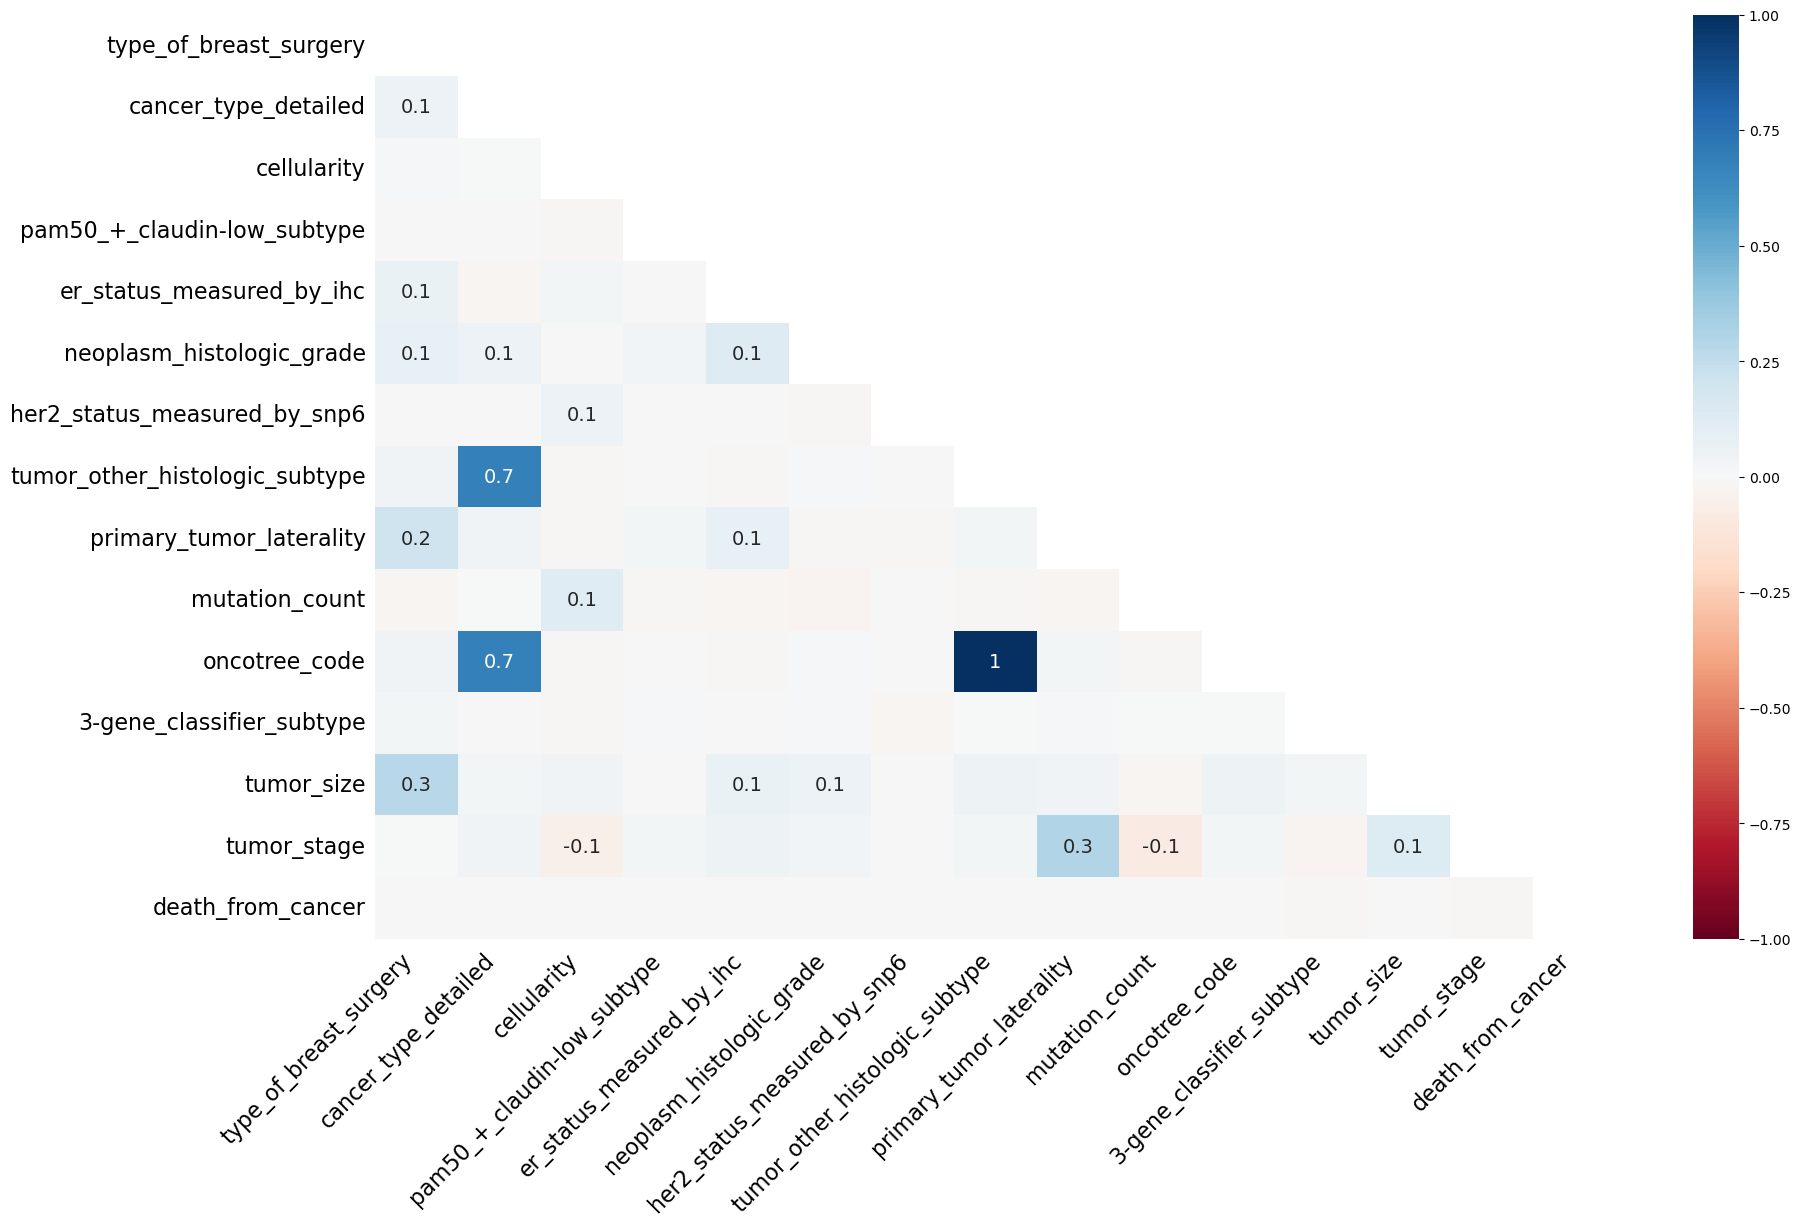

In [6]:
missing_proportion = clinical_df.isnull().sum() / len(clinical_df) * 100
missing_proportion = missing_proportion.sort_values(ascending=False)

cols_with_missing = clinical_df.columns[clinical_df.isnull().any()]
clinical_df_missing = clinical_df[cols_with_missing]

# Plot missingness heatmap
msno.heatmap(clinical_df_missing)
plt.show()

There is a 100% correlation in missingness between oncotree_code and tumor_other_histologic_subtype and 70% correlation in missingness between oncotree_code, tumor_other_histologic_subtype, and cancer_type_detailed. By examining an explicit print of value proportions of each of those columns, the distribution of associated values seem to be the same across the columns:

In [7]:
# List of columns with missing values
cols_of_interest = ['cancer_type_detailed', 'tumor_other_histologic_subtype', 'oncotree_code']

# Iterate over each column
for col in cols_of_interest:
    print(f"Column: {col}")
    
    # Get value counts including NaNs
    value_counts = clinical_df[col].value_counts(dropna=False)  # dropna=False keeps NaN in counts
    total = len(df[col])
    
    # Print value and proportion
    for val, count in value_counts.items():
        prop = count / total
        print(f"  Value: {val} | Proportion: {prop:.2f}")
    
    print("\n" + "-"*50 + "\n")

Column: cancer_type_detailed
  Value: Breast Invasive Ductal Carcinoma | Proportion: 0.79
  Value: Breast Mixed Ductal And Lobular Carcinoma | Proportion: 0.11
  Value: Breast Invasive Lobular Carcinoma | Proportion: 0.07
  Value: nan | Proportion: 0.02
  Value: Breast Invasive Mixed Mucinous Carcinoma | Proportion: 0.01
  Value: Metaplastic Breast Cancer | Proportion: 0.00

--------------------------------------------------

Column: tumor_other_histologic_subtype
  Value: Ductal/Nst | Proportion: 0.76
  Value: Mixed | Proportion: 0.11
  Value: Lobular | Proportion: 0.07
  Value: Medullary | Proportion: 0.01
  Value: Mucinous | Proportion: 0.01
  Value: Tubular/ Cribriform | Proportion: 0.01
  Value: Other | Proportion: 0.01
  Value: nan | Proportion: 0.01
  Value: Metaplastic | Proportion: 0.00

--------------------------------------------------

Column: oncotree_code
  Value: Idc | Proportion: 0.79
  Value: Mdlc | Proportion: 0.11
  Value: Ilc | Proportion: 0.07
  Value: Immc | Propo

We will plot a collinearity matrix to check for collinearity

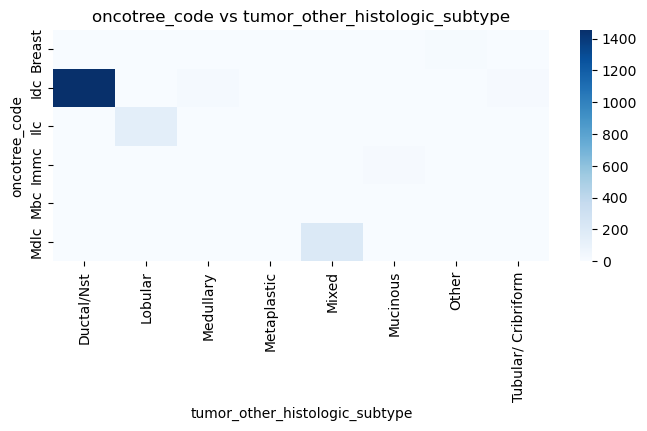

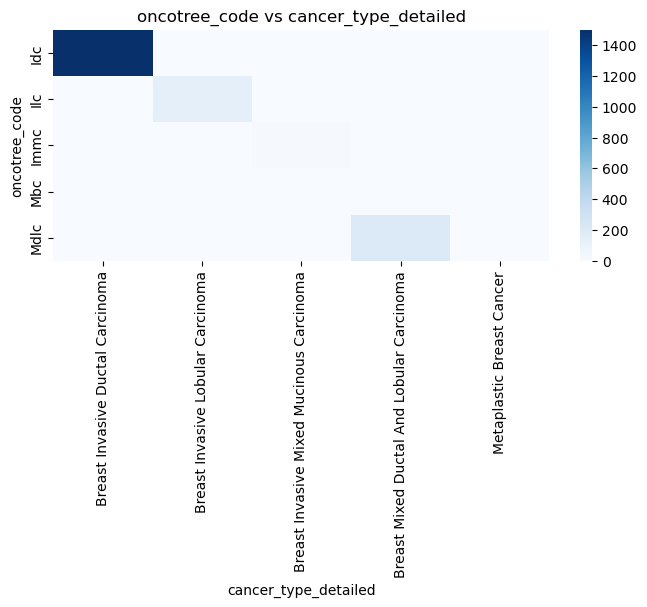

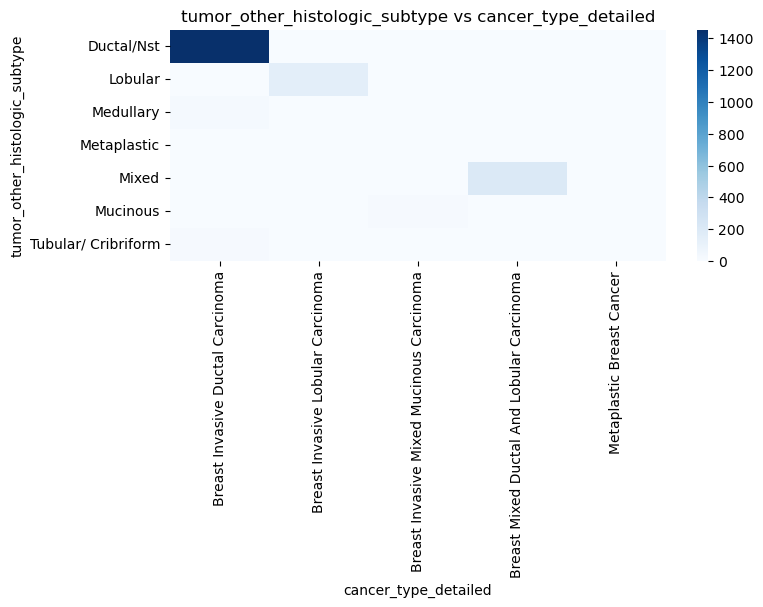

In [8]:
# Function to plot heatmap of counts
def plot_crosstab_heatmap(col1, col2):
    ct = pd.crosstab(df[col1], df[col2])
    plt.figure(figsize=(8,3))
    sns.heatmap(ct, cmap="Blues", annot=False)
    plt.title(f"{col1} vs {col2}")
    plt.xlabel(col2)
    plt.ylabel(col1)
    plt.show()

# ----------------------------
# Plot pairwise combinations
# ----------------------------
plot_crosstab_heatmap('oncotree_code', 'tumor_other_histologic_subtype')
plot_crosstab_heatmap('oncotree_code', 'cancer_type_detailed')
plot_crosstab_heatmap('tumor_other_histologic_subtype', 'cancer_type_detailed')

The three heatmaps show how `oncotree_code`, `tumor_other_histologic_subtype`, and `cancer_type_detailed` relate to each other. Most cases line up across examples so that the label from one column cleanly refers to a value in another column. This means these columns mostly capture the same information but use slightly different labels. The plots indicate that these variables are largely redundant, which explains their highly correlated missingness. For this reason, we will drop two columns. We will keep `cancer_detailed_type`, since it maps almost perfectly to both `oncotree_code` and `tumor_other_histologic_subtype` and has easily interpretable labels.

In [9]:
clinical_df.drop(columns=['oncotree_code', 'tumor_other_histologic_subtype'], inplace=True)

### Multicollinearity

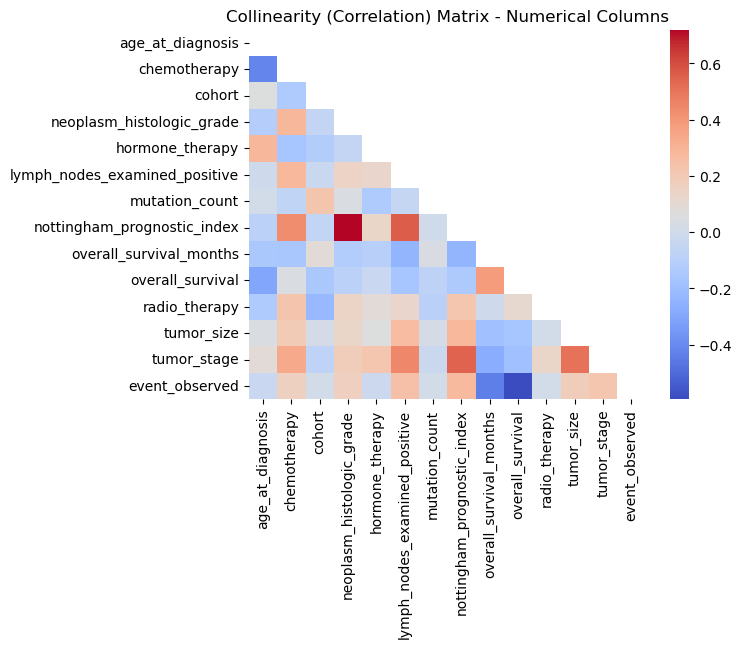

Highly collinear numerical feature pairs (>|0.7|):
[('neoplasm_histologic_grade', 'nottingham_prognostic_index'), ('nottingham_prognostic_index', 'neoplasm_histologic_grade')]


In [10]:
# Select only numerical columns
numeric_clinical_df = clinical_df.select_dtypes(include=[np.number])

# Compute correlation matrix
corr_matrix = numeric_clinical_df.corr()

# Mask upper triangle for cleaner heatmap
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

# Plot heatmap
sns.heatmap(corr_matrix, mask=mask, cmap='coolwarm', annot=False)
plt.title("Collinearity (Correlation) Matrix - Numerical Columns")
plt.show()

# List highly collinear numerical features
threshold = 0.7
high_corr = np.where((corr_matrix.abs() > threshold) & (corr_matrix.abs() < 1))
high_corr_pairs = [(corr_matrix.index[x], corr_matrix.columns[y]) for x, y in zip(*high_corr)]
print("Highly collinear numerical feature pairs (>|0.7|):")
print(high_corr_pairs)

Note that there is only one pair of columns that exceed a correlation of 0.7,`neoplasm_histologic_grade` and `nottingham_prognostic_index`. `neoplasm_histologic_grade` refers to a tumor grade that describes how abnormal the cancer cells look under a microscope (a measure of aggressiveness). `nottingham_prognostic_index` is a derived column that predicts overall prognosis.

For survival analysis, we do not want to use `nottingham_prognostic_index`, because it is essentially a tool to predict survival, so before the models are made, this column will be dropped in favor of `neoplasm_histologic_grade`. But for illustration and analysis purposes, we will temporarily keep both.

## NOTE: For the following, I still need to work on analysis. This section is not complete - Talasia

### Kaplan-Meier Curves: Stratified Comparisans

In [11]:
time_to_event = clinical_df['overall_survival_months']
event = clinical_df['event_observed']

#### a. Tumor Stage

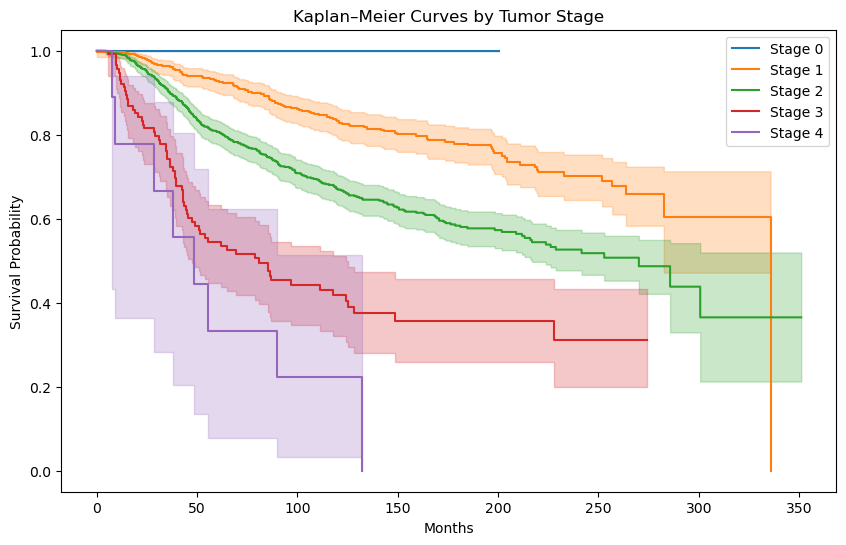

In [12]:
kmf = KaplanMeierFitter()

plt.figure(figsize=(10,6))

for stage in sorted(clinical_df['tumor_stage'].dropna().unique()):
    mask = clinical_df['tumor_stage'] == stage
    kmf.fit(time_to_event[mask], event_observed=event[mask], label=f"Stage {int(stage)}")
    kmf.plot_survival_function(ci_show=True)

plt.title("Kaplan–Meier Curves by Tumor Stage")
plt.xlabel("Months")
plt.ylabel("Survival Probability")
plt.legend()
plt.show()

#### b. Cancer Type

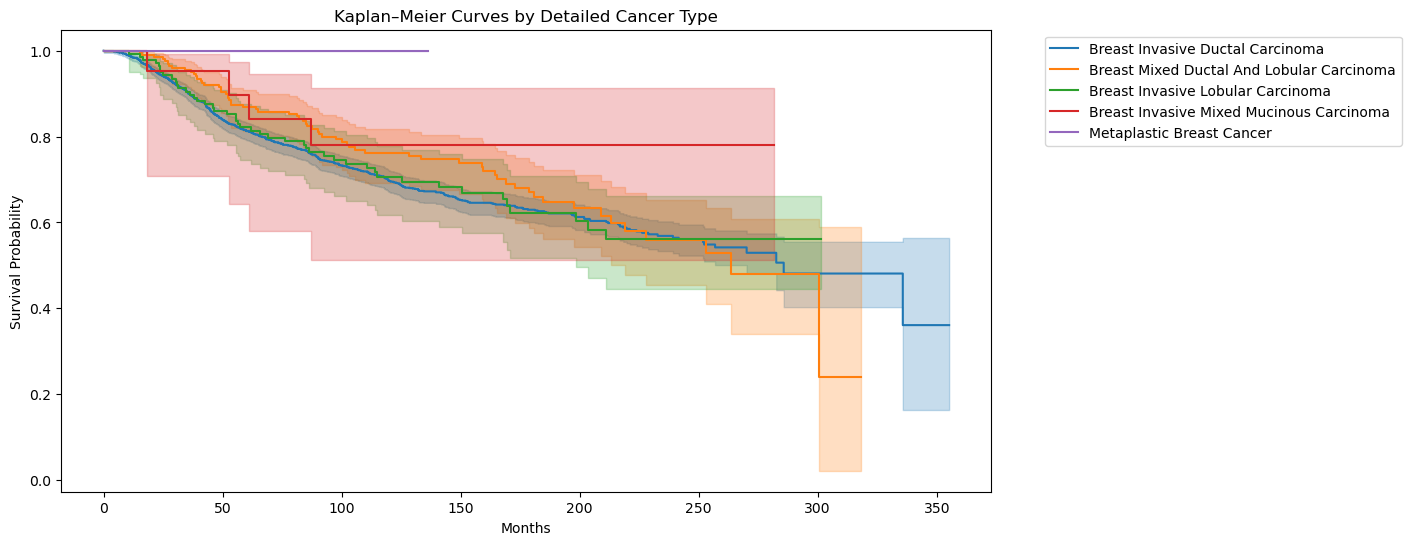

In [13]:
kmf = KaplanMeierFitter()
plt.figure(figsize=(12,6))

for ctype in clinical_df['cancer_type_detailed'].dropna().unique():
    mask = clinical_df['cancer_type_detailed'] == ctype
    kmf.fit(clinical_df['overall_survival_months'][mask], 
            event_observed=clinical_df['event_observed'][mask], 
            label=ctype)
    kmf.plot_survival_function(ci_show=True)

plt.title("Kaplan–Meier Curves by Detailed Cancer Type")
plt.xlabel("Months")
plt.ylabel("Survival Probability")
plt.legend(bbox_to_anchor=(1.05,1))
plt.show()

### Kaplan-Meier Curves: Treatment vs No Treatment

#### a. Chemotherapy

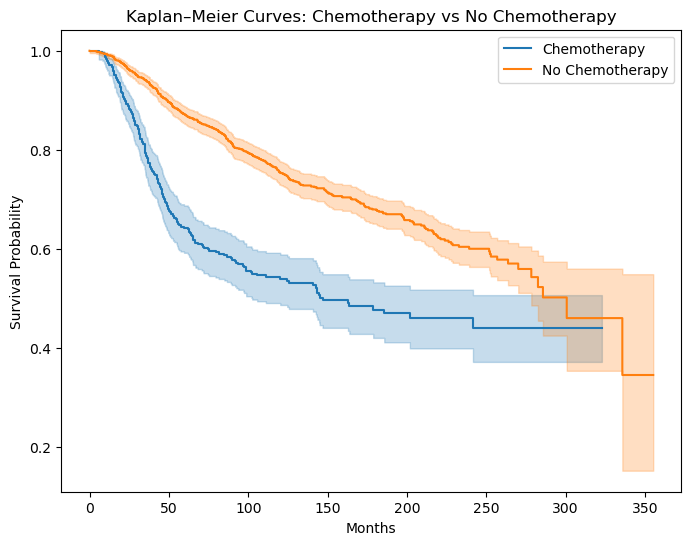

In [14]:
kmf = KaplanMeierFitter()
plt.figure(figsize=(8,6))

for treatment, label in zip([1, 0], ['Chemotherapy', 'No Chemotherapy']):
    mask = clinical_df['chemotherapy'] == treatment
    kmf.fit(time_to_event[mask], event_observed=event[mask], label=label)
    kmf.plot_survival_function(ci_show=True)

plt.title("Kaplan–Meier Curves: Chemotherapy vs No Chemotherapy")
plt.xlabel("Months")
plt.ylabel("Survival Probability")
plt.show()

#### b. Hormone therapy

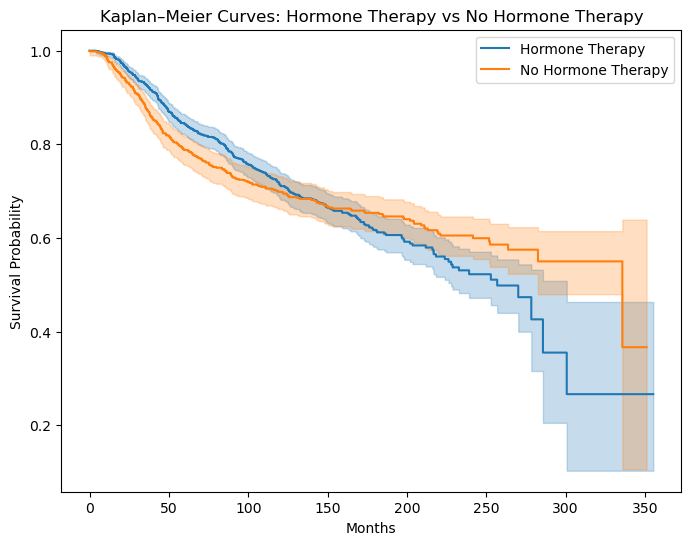

In [15]:
plt.figure(figsize=(8,6))
for treatment, label in zip([1, 0], ['Hormone Therapy', 'No Hormone Therapy']):
    mask = clinical_df['hormone_therapy'] == treatment
    kmf.fit(time_to_event[mask], event_observed=event[mask], label=label)
    kmf.plot_survival_function(ci_show=True)

plt.title("Kaplan–Meier Curves: Hormone Therapy vs No Hormone Therapy")
plt.xlabel("Months")
plt.ylabel("Survival Probability")
plt.show()

#### c. Radiotherapy

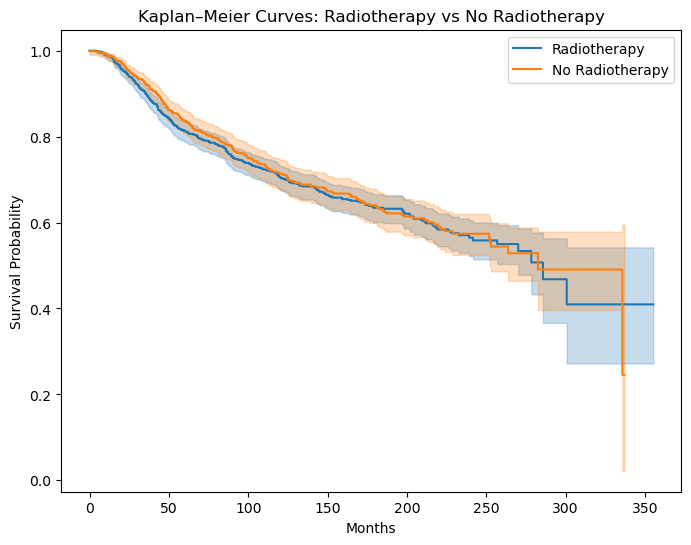

In [16]:
plt.figure(figsize=(8,6))
for treatment, label in zip([1, 0], ['Radiotherapy', 'No Radiotherapy']):
    mask = clinical_df['radio_therapy'] == treatment
    kmf.fit(time_to_event[mask], event_observed=event[mask], label=label)
    kmf.plot_survival_function(ci_show=True)

plt.title("Kaplan–Meier Curves: Radiotherapy vs No Radiotherapy")
plt.xlabel("Months")
plt.ylabel("Survival Probability")
plt.show()

### Section for plot of Cox hazards for continuous variables

Now we can delete the uneeded column:

In [17]:
# clinical_df.drop(columns='nottingham_prognostic_index', inplace=True)

## EDA for Gene Expressions

Notes:


For the gene expression columns, the values are the z-score:


z = (expression in tumor sample - mean expression in reference sample) / standard deviation of expression in reference sample

The calculations of the relative expression of an individual gene and tumor to the gene's expression distribution in a reference population is done. That reference population is all samples in the study . The returned value indicates the number of standard deviations away from the mean of expression in the reference population (Z-score). This measure is useful to determine whether a gene is up- or down-regulated relative to the normal samples or all other tumor samples

489 gene expressions

In [18]:
expression_df.head(10)

,brca1,brca2,palb2,pten,tp53,atm,cdh1,chek2,nbn,nf1,...,srd5a1,srd5a2,srd5a3,st7,star,tnk2,tulp4,ugt2b15,ugt2b17,ugt2b7
0,-1.3990,-0.5738,-1.6217,1.4524,0.3504,1.1517,0.0348,0.1266,-0.8361,-0.8578,...,-1.1877,-0.0194,-1.6345,-0.2142,-0.5698,-1.1741,-1.4779,-0.5954,-0.8847,-0.3354
1,-1.3800,0.2777,-1.2154,0.5296,-0.0136,-0.2659,1.3594,0.7961,0.5419,-2.6059,...,-0.4412,0.4534,0.4068,0.7634,0.0231,0.9121,-0.9538,-0.2264,0.5398,-0.8920
2,0.0670,-0.8426,0.2114,-0.3326,0.5141,-0.0803,1.1398,0.4187,-0.4030,-1.1305,...,-0.5381,0.0668,0.8344,1.7227,0.4024,-3.7172,-1.5538,1.3701,-0.1078,0.3655
3,0.6744,-0.5428,-1.6592,0.6369,1.6708,-0.8880,1.2491,-1.1889,-0.4174,-0.6165,...,-0.5630,-0.7078,0.8228,0.6819,-0.1948,-2.3286,-0.9924,-0.3154,0.2320,-0.4828
4,1.2932,-0.9039,-0.7219,0.2168,0.3484,0.3897,0.9131,0.9356,0.7675,-0.2940,...,-0.5845,-0.3544,-1.0150,2.2961,0.1817,-0.1572,0.0427,5.0048,3.8476,1.3223
5,-0.4341,0.6931,0.6909,1.0840,-1.9371,0.9252,1.1520,0.7951,-0.9677,-0.7750,...,-0.3910,0.0395,0.8191,0.1977,-0.2302,-0.5092,-0.3021,0.9357,-0.4217,0.5340
6,0.2671,0.4129,-1.3333,0.7834,-0.5109,0.8859,-0.2009,1.0128,-0.0697,-0.6300,...,-1.3151,0.0917,1.6814,2.2495,-1.6522,-3.4775,-0.4892,1.1938,-0.1027,0.4331
7,0.3985,1.2710,-1.5306,1.6104,-0.0810,1.3899,-1.1327,0.0384,-0.7457,-2.1944,...,-0.7775,-0.3588,2.4959,0.3744,-0.7101,-2.1453,-1.3027,-0.2308,-0.3450,-0.2023
8,0.8347,-1.5038,0.3436,-0.5550,0.0558,-0.9155,-0.8571,-0.1267,-0.1705,0.6442,...,-0.3917,-0.1405,-0.9780,-0.3030,-0.1640,1.0783,1.8263,-0.5965,0.1502,-0.8837
9,-1.0087,-0.6074,0.0313,1.0975,0.5314,0.9105,-1.5068,-0.0196,0.3726,0.4892,...,-0.3020,-0.4788,3.6125,1.9925,0.2253,-0.8414,1.7093,-0.6921,0.6906,-0.8006


Check for missing values

In [19]:
missing_proportion_exp = expression_df.isnull().sum() / len(expression_df) * 100
missing_proportion_exp = missing_proportion_exp.sort_values(ascending=False)

exp_cols_with_missing = expression_df.columns[expression_df.isnull().any()]
expression_df_missing = expression_df[exp_cols_with_missing]

print(f"Columns with missing values: {len(exp_cols_with_missing)}")

Columns with missing values: 0


No missing values found in any gene expression columns

Transform and scale gene expression data to prevent future issues due to skewed distributions

In [20]:
from sklearn.preprocessing import PowerTransformer, StandardScaler

# transform using Yeo-Johnson
pt = PowerTransformer(method="yeo-johnson")
expression_transformed = pd.DataFrame(pt.fit_transform(expression_df),columns=expression_df.columns, index=expression_df.index)

# check skew after transformation
skew_after = expression_transformed.skew()
still_skewed = skew_after[abs(skew_after) > 2].index.tolist()
print(f"Number of genes that still have a skewed distribution: {len(still_skewed)}")

# scale data
scaler = StandardScaler()
expression_scaled = pd.DataFrame(scaler.fit_transform(expression_transformed.drop(columns=still_skewed)),
    columns=expression_transformed.drop(columns=still_skewed).columns, index=expression_transformed.index)

Number of genes that still have a skewed distribution: 0


Remove genes with near-zero variance to reduce noise and dimensionality

In [21]:
from sklearn.feature_selection import VarianceThreshold

selector = VarianceThreshold(threshold=0.5)
selector.fit(expression_scaled.dropna())
low_var_genes = expression_scaled.columns[~selector.get_support()].tolist()

print(f"Low variance genes: {len(low_var_genes)}")

Low variance genes: 0


No genes were found to have near-zero variance across a large range of thresholds

Correlation

In [22]:
# calculate correlations
corr = expression_scaled.corr()

# find highly correlated pairs of genes
# use a threshold of 0.8
high_corr = (corr.abs() > 0.8) & (corr != 1.0)
pairs = [(corr.index[i], corr.columns[j], corr.iloc[i,j])
         for i in range(len(corr)) for j in range(i+1, len(corr))
         if high_corr.iloc[i, j]]

# print the highly correlated pairs
print(f"Highly correlated pairs (|r|>0.85): {len(pairs)}")
print(pairs)

Highly correlated pairs (|r|>0.85): 3
[('pdgfrb', 'col6a3', np.float64(0.8305414315931895)), ('akr1c2', 'akr1c4', np.float64(0.8315786077155263)), ('akr1c3', 'akr1c4', np.float64(0.8498455131883659))]


Pairs found to have high correlation:

'pdgfrb', 'col6a3'

'akr1c2', 'akr1c4'

'akr1c3', 'akr1c4'

Potentially drop akr1c4 for Cox regression, since it has high correlation with 2 other genes

or

create interaction terms

Elbow plot for choosing # of clusters - we want to see if there is any natural clustering of the gene expressions

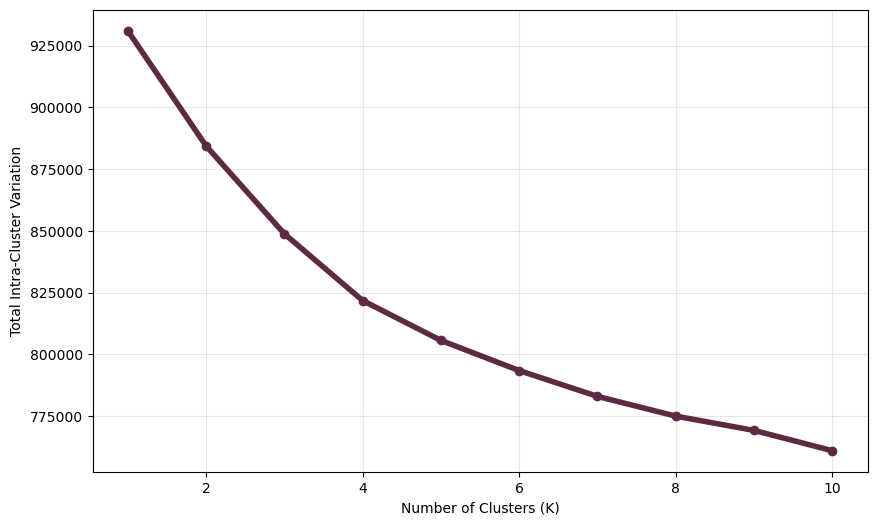

In [23]:
# record total intra-cluster variation
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

ticv = []

# test various values of K to find the best one
for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, n_init=20)

    # fit kmeans algorithm
    kmeans.fit(expression_scaled)

    # record total intra-cluster variation for K=k
    ticv.append(kmeans.inertia_)

# create elbow plot
fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(range(1, 11), ticv, linewidth=4, marker="o", c="#5e2943")
ax.set_xlabel("Number of Clusters (K)")
ax.set_ylabel("Total Intra-Cluster Variation")
ax.grid(True, alpha=0.3)
plt.show()

There is a slight elbow around K=4, choose 4 as # of clusters

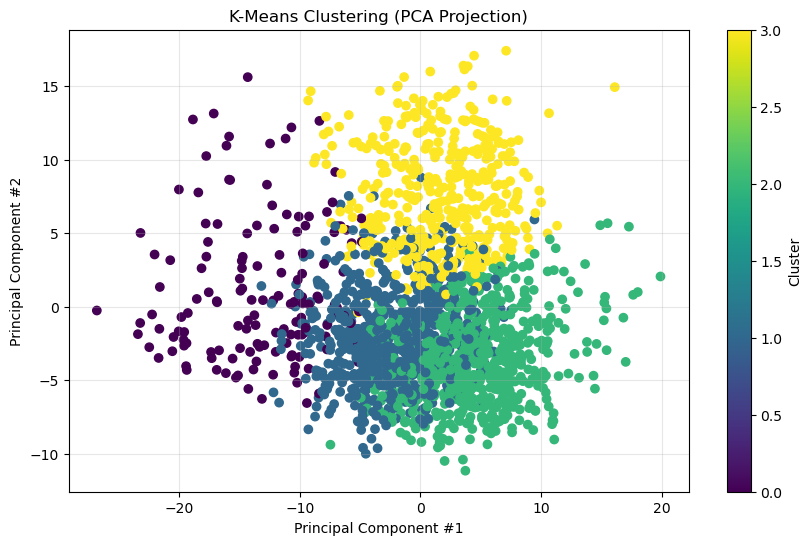

In [24]:
# calculate/fit k-means with 4 clusters
kmeans = KMeans(n_clusters=4, n_init=20)
y_kmeans = kmeans.fit_predict(expression_scaled)

# apply PCA for visualization purposes
pca = PCA(n_components=2)
expression_pca = pca.fit_transform(expression_scaled)

# plot clusters using PCA projection
fig, ax = plt.subplots(figsize=(10, 6))
scatter = ax.scatter(expression_pca[:, 0], expression_pca[:, 1], c=y_kmeans)
ax.set_xlabel("Principal Component #1")
ax.set_ylabel("Principal Component #2")
ax.set_title("K-Means Clustering (PCA Projection)")
plt.colorbar(scatter, ax=ax, label="Cluster")
ax.grid(True, alpha=0.3)
plt.show()

## EDA for Gene Mutations

In [25]:
mutation_mask = mutations_df.apply(lambda col: col.astype(str).str.strip() != '0')
mutation_counts = mutation_mask.sum().sort_values(ascending=False)
mutation_counts.head(10)

pik3ca_mut    795
tp53_mut      659
muc16_mut     326
ahnak2_mut    311
kmt2c_mut     234
syne1_mut     232
gata3_mut     230
map3k1_mut    198
ahnak_mut     176
dnah11_mut    175
dtype: int64

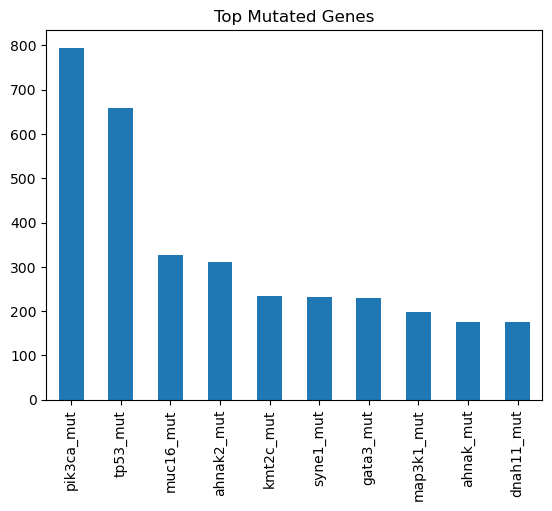

In [26]:
mutation_counts.head(10).plot(kind='bar')
plt.title("Top Mutated Genes")
plt.show()

In [27]:
mutations_per_patient = mutation_mask.sum(axis=1)
mutations_per_patient.describe()

count    1904.000000
mean        5.115021
std         3.351521
min         0.000000
25%         3.000000
50%         5.000000
75%         7.000000
max        48.000000
dtype: float64

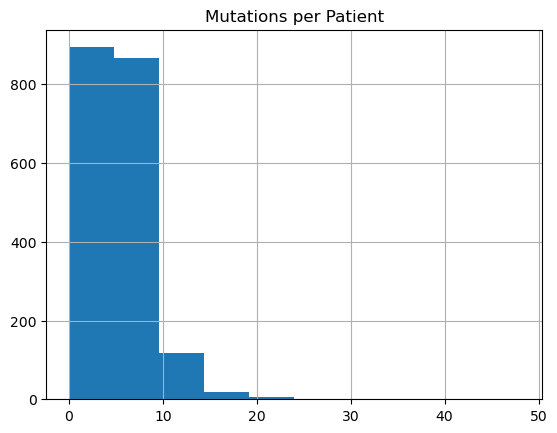

In [28]:
mutations_per_patient.hist()
plt.title("Mutations per Patient")
plt.show()

## Spectral Clustering

In [30]:
data = mutations_df.apply(lambda col: col.astype(str).str.strip() != '0').astype(int)

In [31]:
from sklearn.cluster import SpectralClustering
sc = SpectralClustering(n_clusters=3, affinity='nearest_neighbors')
labels = sc.fit_predict(data)

In [32]:
from sklearn.cluster import KMeans
kmeans = KMeans(n_clusters=3)
k_labels = kmeans.fit_predict(data)

In [33]:
from sklearn.decomposition import PCA
pca = PCA(n_components=2)
reduced_data = pca.fit_transform(data)

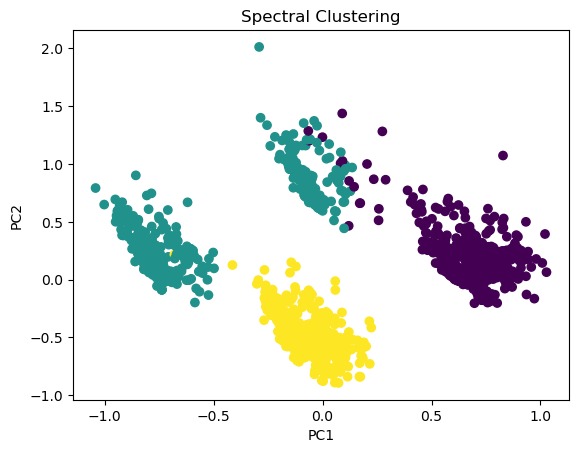

In [34]:
plt.scatter(reduced_data[:, 0], reduced_data[:, 1], c=labels)
plt.title("Spectral Clustering")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()

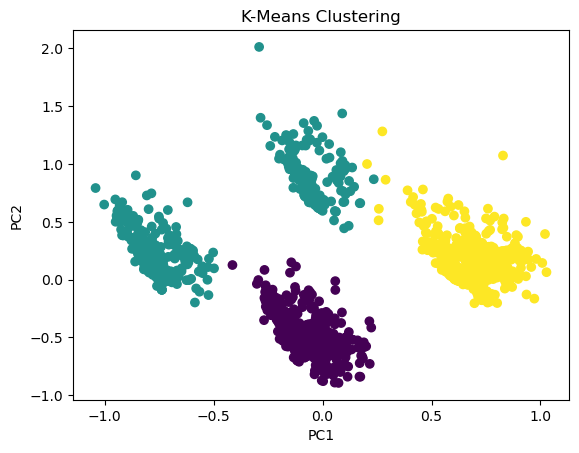

In [35]:
plt.scatter(reduced_data[:, 0], reduced_data[:, 1], c=k_labels)
plt.title("K-Means Clustering")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()